# Potts model: simulate, fit, search, learn

One pass through the repository's Potts instance, from a seeded fixture to a
learned search policy, with every claim checked against an oracle that shares
no code with what it checks.

**Scope.** This is the **1-D chain in an external field**. The N-D lattice
and the general Markov random field `ROADMAP.md` §1.1 specifies landed after
this notebook was written (`snakes_and_ladders.sim.graph`, `snakes_and_ladders.sim.potts`; #190,
closing #170), and are not covered here. The Further Work section at the end
says what a lattice pass would add.

The model, for `q` states on a chain of length `L`:

$$P(s) \propto \exp\left(J \sum_i \delta(s_i, s_{i+1}) + \sum_i h[s_i]\right)$$

with `J` a scalar coupling and `h` an external field. The normalizer is exact
by transfer matrix, which is what makes every claim below checkable.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from snakes_and_ladders.learn.policy import LinearPolicy
from snakes_and_ladders.learn.potts import (
    PottsLandscape,
    enumerate_configurations,
    optimum,
)
from snakes_and_ladders.learn.reinforce import reinforce
from snakes_and_ladders.learn.rollout import greedy_rollout, rollout
from snakes_and_ladders.opt.fit import constrained_standard_errors, covers, fit
from snakes_and_ladders.opt.potts import (
    PottsObjective,
    load_potts_params,
    log_partition,
    simulate_chains,
)

# Resolve the repository root from wherever the notebook is opened.
REPOSITORY = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").is_file()
)
FIXTURE = REPOSITORY / "tests/regression/fixtures/potts_params.yaml"

params = load_potts_params(FIXTURE)
print(f"states      {params.n_states}")
print(f"chain length {params.chain_length}")
print(f"chains      {params.n_chains}")
print(f"coupling J  {params.coupling}")
print(f"field h     {np.round(params.field, 4)}  (gauge: logsumexp(h) == 0)")
print(f"seed        {params.seed}")

states      3
chain length 12
chains      400
coupling J  0.75
field h     [-0.7434 -1.2434 -1.4434]  (gauge: logsumexp(h) == 0)
seed        20260902


## 1. Simulated data from a declared truth

The fixture states the truth; the simulator draws from it under a seeded
generator, so every number below reproduces from the yaml alone.

In [2]:
chains = simulate_chains(params)
print(f"simulated {chains.shape[0]} chains of length {chains.shape[1]}")
print("first three chains:")
print(chains[:3])

simulated 400 chains of length 12
first three chains:
[[2 0 0 0 0 0 2 2 0 0 0 0]
 [1 1 2 1 0 0 0 2 2 0 0 0]
 [0 0 1 1 1 2 0 1 1 0 0 0]]


## 2. The normalizer, against exhaustive enumeration

`log_partition` runs a transfer-matrix recursion in log space. Enumerating
every configuration sums the same quantity directly, sharing no code with it,
and costs `q**L` — which is why the check runs at `L = 6` and the fit does
not.

In [3]:
CHECK_LENGTH = 6
field = torch.as_tensor(params.field)
coupling = torch.tensor(params.coupling, dtype=torch.float64)

configurations = torch.tensor(
    list(enumerate_configurations(params.n_states, CHECK_LENGTH)), dtype=torch.long
)
agreements = (configurations[:, 1:] == configurations[:, :-1]).sum(dim=1)
energies = coupling * agreements + field[configurations].sum(dim=1)

enumerated = torch.logsumexp(energies, dim=0)
recursion = log_partition(coupling, field, CHECK_LENGTH)
deviation = abs(float(recursion - enumerated) / float(enumerated))
print(f"enumerated over {len(configurations)} configurations: {float(enumerated):.12f}")
print(f"transfer matrix:                        {float(recursion):.12f}")
print(f"relative deviation: {deviation:.2e}  (float64 epsilon 2.22e-16)")

enumerated over 729 configurations: 1.745790968912
transfer matrix:                        1.745790968912
relative deviation: 1.27e-16  (float64 epsilon 2.22e-16)


## 3. Fitting `J` and `h` by autodiff

`snakes_and_ladders.opt.fit` is model-agnostic: it sees an unconstrained parameter vector,
a differentiable scalar, and a map back to named constrained parameters. The
same call fits the hidden Markov model in `hmm.ipynb` and branch lengths in
`phylo_tree.ipynb`.

In [4]:
objective = PottsObjective(chains, params.n_states)
GRADIENT_TOLERANCE = 1e-8
result = fit(objective, gradient_tolerance=GRADIENT_TOLERANCE)
estimate = objective.constrain(result.theta)
error = constrained_standard_errors(objective, result.theta)

truth = torch.cat([coupling.reshape(1), field])
fitted = torch.cat([estimate["coupling"].reshape(1), estimate["field"]])
spread = torch.cat([error["coupling"].reshape(1), error["field"]])
hits = covers(fitted, spread, truth)

# The residual gradient norm is *not* printed. It is a near-zero number
# whose value is floating-point noise -- it moved from 6.5e-10 to 1.7e-10
# between two machines running this same cell, while every fitted
# parameter agreed to four decimals. `docs/CLAUDE.md` forbids the same
# thing in a generated caption for the same reason. What carries
# information is that the norm cleared the tolerance, so that is printed.
print(
    f"converged: {result.converged}, {result.iterations} L-BFGS steps, "
    f"relative gradient norm below {GRADIENT_TOLERANCE:.0e}\n"
)
print(f"{'parameter':<10}{'truth':>10}{'fitted':>10}{'std err':>10}   95% interval")
for name, true_value, point, deviation_, covered in zip(
    ["J", "h[0]", "h[1]", "h[2]"], truth, fitted, spread, hits, strict=True
):
    verdict = "covers" if bool(covered) else "MISSES"
    print(
        f"{name:<10}{float(true_value):>10.4f}{float(point):>10.4f}"
        f"{float(deviation_):>10.4f}   {verdict}"
    )
print(f"\n{int(hits.sum())} of {len(hits)} intervals cover their truth")

converged: True, 1 L-BFGS steps, relative gradient norm below 1e-08

parameter      truth    fitted   std err   95% interval
J             0.7500    0.7158    0.0327   covers
h[0]         -0.7434   -0.7439    0.0140   covers
h[1]         -1.2434   -1.2470    0.0201   covers
h[2]         -1.4434   -1.4380    0.0252   covers

4 of 4 intervals cover their truth


Coverage on one dataset is a draw, not a rate. The nominal 0.95 is checked
over independent replicates by the release-gated regression suite and plotted
in `docs/tex/figures/opt_coverage.pdf`, where the realized rate is 96/100 at
1600 chains.

## 4. Discrete search, where the answer is enumerable

Fitting is continuous; search is not. The landscape below is the same model
read as a search problem: a state is a configuration, an action is a
single-site flip, and the objective is the energy.

It runs at `L = 4` rather than the fixture's 12 because the claim being made
is *did the search find the best configuration*, and answering that needs all
`3**4 = 81` configurations enumerated. At `L = 12` there are 531,441.

In [5]:
SEARCH_LENGTH = 4
HORIZON = 6

landscape = PottsLandscape(params.coupling, params.field, SEARCH_LENGTH)
starts = list(enumerate_configurations(params.n_states, SEARCH_LENGTH))
best_configuration, best_energy = optimum(landscape)

print(f"{len(starts)} configurations enumerated")
print(f"global optimum {best_configuration} at energy {best_energy:.4f}")
print(f"actions per state: {len(landscape.actions(starts[0]))}")

81 configurations enumerated
global optimum (0, 0, 0, 0) at energy -0.7237
actions per state: 8


In [6]:
greedy_finals = [
    landscape.energy(greedy_rollout(landscape, start, HORIZON).states[-1])
    for start in starts
]
greedy_hits = np.mean([abs(value - best_energy) < 1e-9 for value in greedy_finals])
print(f"hill climbing from all {len(starts)} starts, {HORIZON} steps each")
print(f"  mean final energy {np.mean(greedy_finals):.4f}  (optimum {best_energy:.4f})")
print(f"  reached the optimum from {greedy_hits:.1%} of starts")

hill climbing from all 81 starts, 6 steps each
  mean final energy -1.1780  (optimum -0.7237)
  reached the optimum from 80.2% of starts


## 5. Training data, and a learned policy

Hill climbing leaves 19.8% of starts short. The policy scores each available
flip by two features — the change in agreement and the change in field — and
samples from a softmax over those scores. Training data is the episodes it
rolls out: `iterations x batch` of them, each `HORIZON` steps.

Hill climbing is *inside* this policy class, at the weight vector
proportional to `(J, 1)`, so beating it is a statement about learning rather
than about two unrelated algorithms.

In [7]:
ITERATIONS, BATCH = 60, 32

policy = LinearPolicy(landscape.n_features())
training = reinforce(
    landscape,
    policy,
    np.random.default_rng(0),
    iterations=ITERATIONS,
    batch=BATCH,
    max_steps=HORIZON,
)
print(f"{training.episodes} episodes sampled over {ITERATIONS} iterations")
print(f"learned weights {policy.weights.detach().numpy().round(4)}")
print(f"greedy weights  {landscape.greedy_weights().numpy()}")

1920 episodes sampled over 60 iterations
learned weights [0.9103 2.4172]
greedy weights  [0.75 1.  ]


In [8]:
ROLLOUTS_PER_START = 16

rng = np.random.default_rng(3)
learned_finals = [
    landscape.energy(rollout(landscape, policy, rng, HORIZON, start=start).states[-1])
    for start in starts
    for _ in range(ROLLOUTS_PER_START)
]
learned_hits = np.mean([abs(value - best_energy) < 1e-9 for value in learned_finals])

print(f"{'':<18}{'mean final E':>14}{'reached optimum':>18}")
print(f"{'hill climbing':<18}{np.mean(greedy_finals):>14.4f}{greedy_hits:>17.1%}")
print(f"{'learned policy':<18}{np.mean(learned_finals):>14.4f}{learned_hits:>17.1%}")
print(f"{'enumerated optimum':<18}{best_energy:>14.4f}{1.0:>17.1%}")

                    mean final E   reached optimum
hill climbing            -1.1780            80.2%
learned policy           -0.9965            87.0%
enumerated optimum       -0.7237           100.0%


The sampled return the training loop reports is a diagnostic, not the result:
it is a Monte Carlo estimate under a changing policy, and a score-function
estimator with a sign error rises too. The result is the comparison above,
against exhaustive enumeration.

## 6. Energy against step within an episode

What the two searchers do, step by step, against the enumerated optimum.

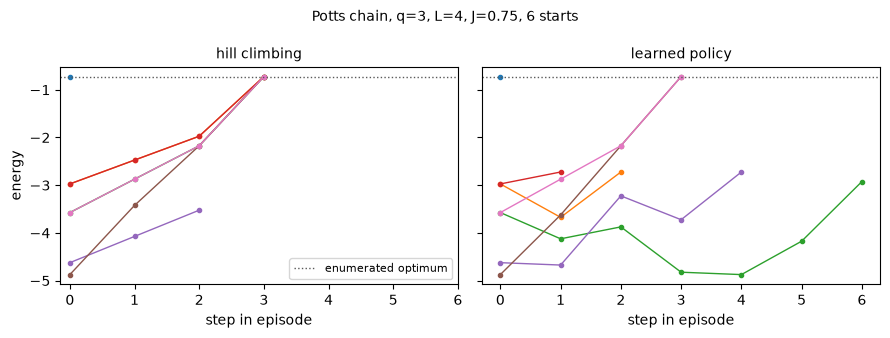

In [9]:
PROBE_STARTS = 6

figure, axes = plt.subplots(1, 2, figsize=(9.0, 3.4), sharey=True)
probe_rng = np.random.default_rng(11)
probes = [starts[index] for index in range(0, len(starts), len(starts) // PROBE_STARTS)]

for axis, label, episodes in (
    (
        axes[0],
        "hill climbing",
        [greedy_rollout(landscape, start, HORIZON) for start in probes],
    ),
    (
        axes[1],
        "learned policy",
        [
            rollout(landscape, policy, probe_rng, HORIZON, start=start)
            for start in probes
        ],
    ),
):
    for episode in episodes:
        trace = [landscape.energy(state) for state in episode.states]
        axis.plot(range(len(trace)), trace, marker="o", markersize=3, linewidth=1.0)
    axis.axhline(
        best_energy,
        color="0.35",
        linestyle=":",
        linewidth=1.0,
        label="enumerated optimum",
    )
    axis.set_title(label, fontsize=10)
    axis.set_xlabel("step in episode")
    axis.set_xticks(range(HORIZON + 1))
axes[0].set_ylabel("energy")
axes[0].legend(fontsize=8, loc="lower right")
figure.suptitle(
    f"Potts chain, q={params.n_states}, L={SEARCH_LENGTH}, J={params.coupling}, "
    f"{PROBE_STARTS} starts",
    fontsize=10,
)
figure.tight_layout()
plt.show()

## Further work

What this notebook does not demonstrate. Each line names the issue that
carries it, and whether the gap is capability or coverage.

- **The 2-D lattice and general MRFs (#190, closing #170).**
  `snakes_and_ladders.sim.graph.PottsGraph` and `snakes_and_ladders.sim.potts.simulate_potts` landed
  after this notebook was written, so the gap is coverage, not capability:
  everything above is the 1-D chain, and a lattice pass needs its own
  notebook.
- **Belief propagation (#206, closing #172).** The exact transfer matrix in
  §2 is available because the chain is a tree. `snakes_and_ladders.likelihood.belief_propagation`
  has since landed and runs on the loopy lattice, where the normalizer needs
  it; that comparison is not made here.
- **Cluster updates (#212, closing #174).** Single-site flips are the only
  move set shown. `snakes_and_ladders.search.potts_mcmc` has since landed with
  Swendsen-Wang and Wolff, so the autocorrelation comparison they permit is
  available and not made here.
- **Fitting on the lattice (`TICKETS.md` §1.3).** The recovery in §3 is for
  the chain's `J` and `h`. Lattice couplings have no fit and no measured
  interval coverage.
- **Re-execution in CI.** This notebook is committed with its outputs, and no
  job re-runs it: Jupyter is not a dependency of this repository. The numbers
  above therefore date from the commit that wrote them, unlike the figures in
  `docs/tex/`, which CI regenerates and byte-compares on every pull request.